In [1]:
# DS605 Lab 4
# End-to-End Machine Learning Project: Airbnb Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("AB_NYC_2019.csv")

# Display first 5 rows
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (48895, 16)

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude         

In [3]:
# Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [4]:
# Count missing values
missing_values = df.isnull().sum()

# Show only columns having missing values
missing_values[missing_values > 0].sort_values(ascending=False)

last_review          10052
reviews_per_month    10052
host_name               21
name                    16
dtype: int64

In [5]:
# Count duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
# Basic information about price
print("Minimum price:", df["price"].min())
print("Maximum price:", df["price"].max())
print("Average price:", df["price"].mean())
print("Median price:", df["price"].median())

Minimum price: 0
Maximum price: 10000
Average price: 152.7206871868289
Median price: 106.0


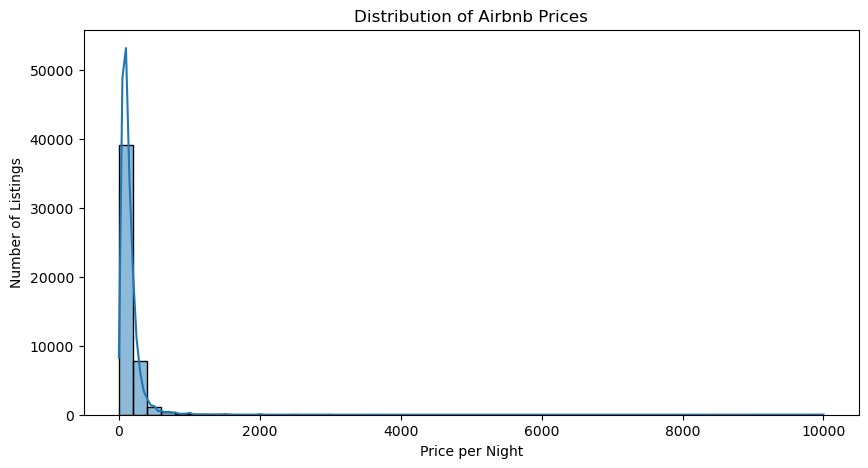

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night")
plt.ylabel("Number of Listings")
plt.show()

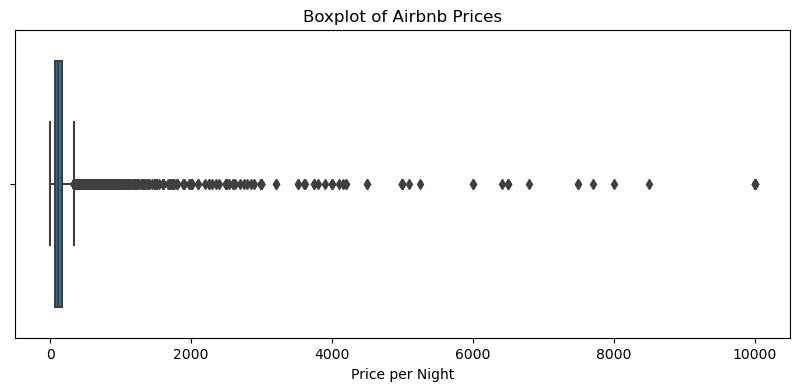

In [8]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price per Night")
plt.show()

In [9]:
# Make a copy of the original dataset
df_clean = df.copy()

# --------------------------------------------------
# 1. Remove rows where price is zero
# --------------------------------------------------

df_clean = df_clean[df_clean["price"] > 0]

# --------------------------------------------------
# 2. Handle missing values
# --------------------------------------------------

# Missing name and host_name are not useful for prediction
df_clean["name"] = df_clean["name"].fillna("Unknown")
df_clean["host_name"] = df_clean["host_name"].fillna("Unknown")

# Listings with no reviews have no monthly review rate
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

# last_review is not needed for our initial model
df_clean = df_clean.drop(columns=["last_review"])

# --------------------------------------------------
# 3. Remove unnecessary ID columns
# --------------------------------------------------

df_clean = df_clean.drop(columns=["id", "host_id"])

# --------------------------------------------------
# Check result
# --------------------------------------------------

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Original dataset shape: (48895, 16)
Cleaned dataset shape: (48884, 13)

Missing values after cleaning:
Series([], dtype: int64)


In [10]:
# --------------------------------------------------
# Handle price outliers using IQR method
# --------------------------------------------------

Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Count outliers
outliers = df_clean[
    (df_clean["price"] < lower_bound) |
    (df_clean["price"] > upper_bound)
]

print("\nNumber of price outliers:", len(outliers))

# Remove price outliers
df_clean = df_clean[
    (df_clean["price"] >= lower_bound) &
    (df_clean["price"] <= upper_bound)
]

print("\nDataset shape after outlier removal:", df_clean.shape)

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower Bound: -90.0
Upper Bound: 334.0

Number of price outliers: 2972

Dataset shape after outlier removal: (45912, 13)


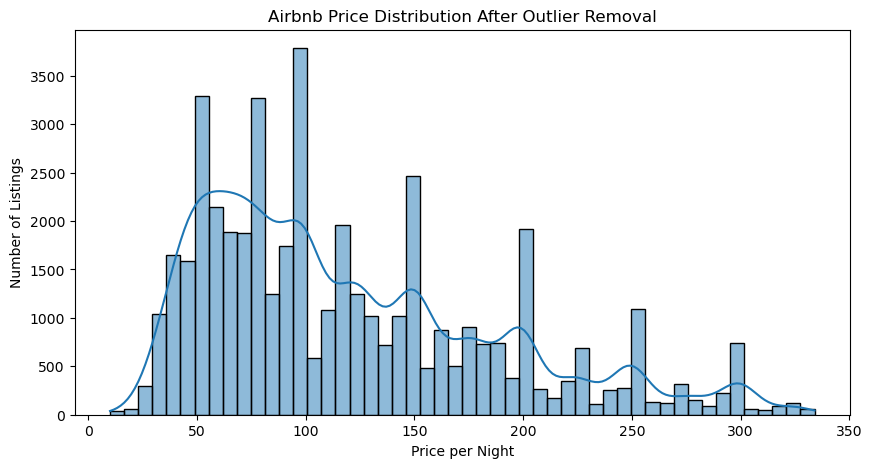

In [11]:
# --------------------------------------------------
# Check price distribution after outlier removal
# --------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(df_clean["price"], bins=50, kde=True)

plt.title("Airbnb Price Distribution After Outlier Removal")
plt.xlabel("Price per Night")
plt.ylabel("Number of Listings")

plt.show()

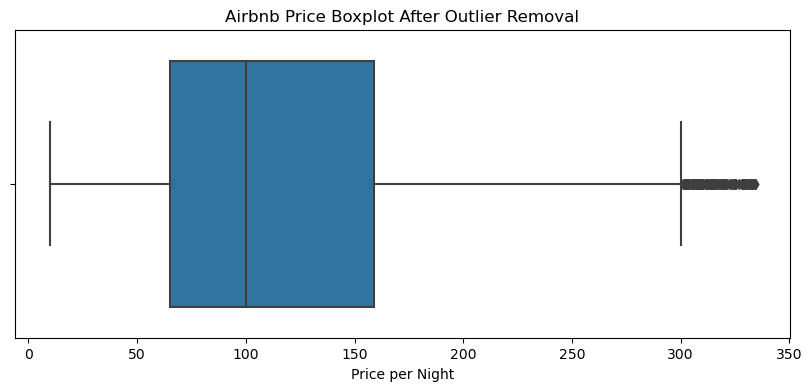

In [12]:
# Boxplot after outlier removal

plt.figure(figsize=(10, 4))

sns.boxplot(x=df_clean["price"])

plt.title("Airbnb Price Boxplot After Outlier Removal")
plt.xlabel("Price per Night")

plt.show()

In [13]:
# --------------------------------------------------
# Step 12: Feature Analysis
# --------------------------------------------------

# Display all remaining columns
print("Remaining columns:")
print(df_clean.columns.tolist())

print("\nDataset shape:")
print(df_clean.shape)

# Numerical columns
print("\nNumerical columns:")
print(df_clean.select_dtypes(include=np.number).columns.tolist())

# Categorical columns
print("\nCategorical columns:")
print(df_clean.select_dtypes(include="object").columns.tolist())

Remaining columns:
['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Dataset shape:
(45912, 13)

Numerical columns:
['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Categorical columns:
['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type']


In [15]:
# --------------------------------------------------
# Numerical Feature Correlation with Price
# --------------------------------------------------

numeric_df = df_clean.select_dtypes(include=np.number)

correlation = numeric_df.corr()["price"].sort_values(ascending=False)

print("Correlation with Price:")
print(correlation)

Correlation with Price:
price                             1.000000
calculated_host_listings_count    0.174409
latitude                          0.068747
availability_365                  0.066670
minimum_nights                    0.031476
number_of_reviews                -0.027606
reviews_per_month                -0.047293
longitude                        -0.306968
Name: price, dtype: float64


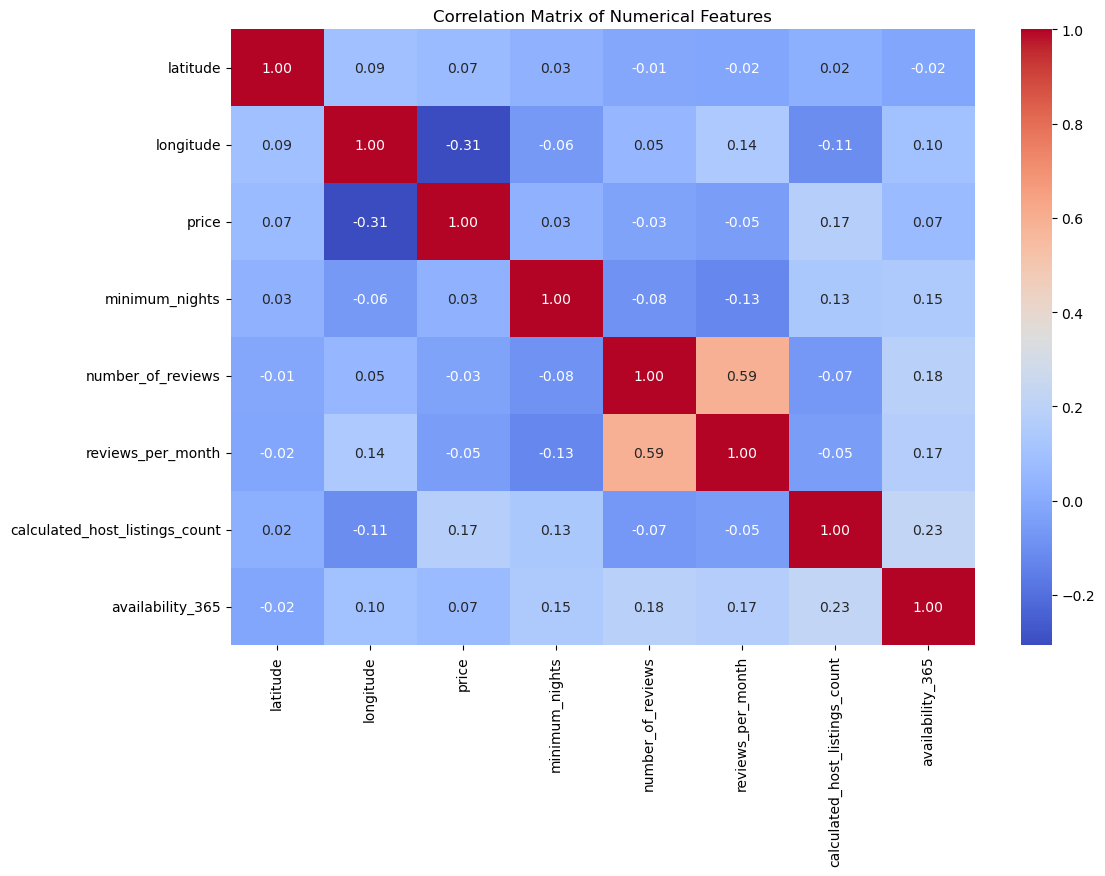

In [16]:
# --------------------------------------------------
# Visualize Correlation Matrix
# --------------------------------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [17]:
# --------------------------------------------------
# Correlation of Numerical Features with Price
# --------------------------------------------------

numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

price_correlation = (
    df_clean[numeric_columns]
    .corr()["price"]
    .sort_values(ascending=False)
)

print("Correlation of numerical features with price:")
print(price_correlation)

Correlation of numerical features with price:
price                             1.000000
calculated_host_listings_count    0.174409
latitude                          0.068747
availability_365                  0.066670
minimum_nights                    0.031476
number_of_reviews                -0.027606
reviews_per_month                -0.047293
longitude                        -0.306968
Name: price, dtype: float64


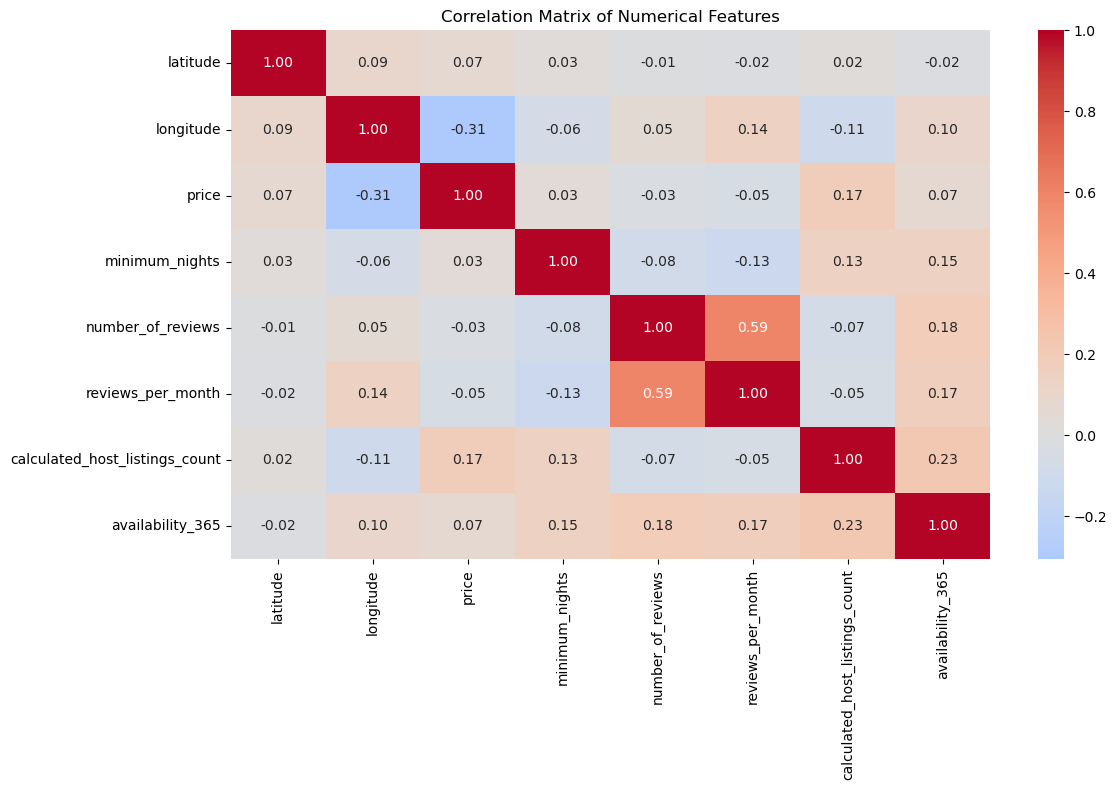

In [18]:
# --------------------------------------------------
# Correlation Heatmap
# --------------------------------------------------

plt.figure(figsize=(12, 8))

correlation_matrix = df_clean[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [19]:
# --------------------------------------------------
# Average Price by Neighbourhood Group
# --------------------------------------------------

avg_price_neighbourhood = (
    df_clean.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Price by Neighbourhood Group:")
print(avg_price_neighbourhood)

Average Price by Neighbourhood Group:
neighbourhood_group
Manhattan        145.960318
Brooklyn         105.748634
Staten Island     89.235616
Queens            88.904437
Bronx             77.437792
Name: price, dtype: float64


In [20]:
# --------------------------------------------------
# Average Price by Room Type
# --------------------------------------------------

avg_price_room = (
    df_clean.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Price by Room Type:")
print(avg_price_room)

Average Price by Room Type:
room_type
Entire home/apt    162.541361
Private room        79.043658
Shared room         59.397887
Name: price, dtype: float64


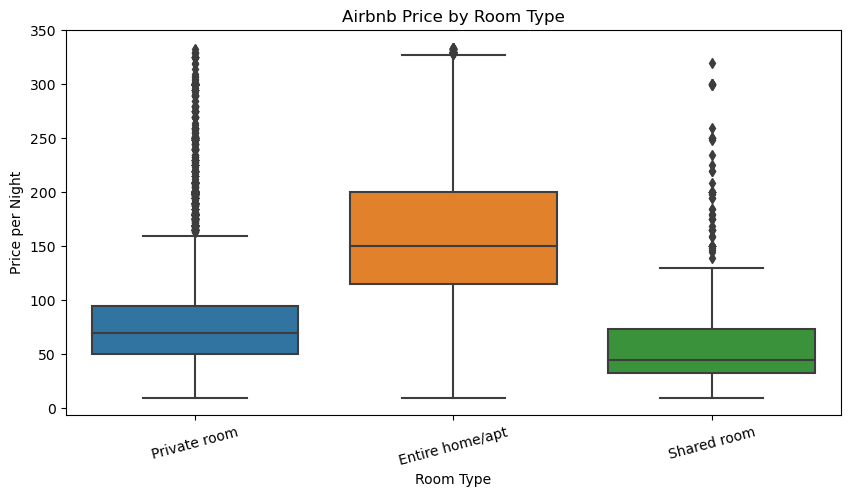

In [21]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x="room_type",
    y="price"
)

plt.title("Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price per Night")
plt.xticks(rotation=15)

plt.show()

In [22]:
# --------------------------------------------------
# Feature Selection
# --------------------------------------------------

# Features selected for prediction
selected_features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

# Create final modeling dataset
model_df = df_clean[selected_features + ["price"]].copy()

print("Selected Features:")
print(selected_features)

print("\nModeling Dataset Shape:")
print(model_df.shape)

print("\nModeling Dataset Preview:")
display(model_df.head())

Selected Features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Modeling Dataset Shape:
(45912, 11)

Modeling Dataset Preview:


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,1,9,0.21,6,365,149
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,45,0.38,2,355,225
2,Manhattan,Harlem,40.80902,-73.94190,Private room,3,0,0.00,1,365,150
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,270,4.64,1,194,89
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,10,9,0.10,1,0,80


In [23]:
# --------------------------------------------------
# Separate Features and Target
# --------------------------------------------------

X = model_df.drop("price", axis=1)
y = model_df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget summary:")
print(y.describe())

X shape: (45912, 10)
y shape: (45912,)

Feature columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Target summary:
count    45912.000000
mean       119.999063
std         68.133003
min         10.000000
25%         65.000000
50%        100.000000
75%        159.000000
max        334.000000
Name: price, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split

# --------------------------------------------------
# Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36729, 10)
Testing data: (9183, 10)


In [25]:
# --------------------------------------------------
# Preprocessing Pipeline
# --------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Categorical features
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

# Numerical features
numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")
print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Preprocessing pipeline created successfully.

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type']

Numerical features:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [26]:
# --------------------------------------------------
# Apply Preprocessing
# --------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (36729, 10)
Processed training shape: (36729, 232)

Original testing shape: (9183, 10)
Processed testing shape: (9183, 232)


In [27]:
# Check whether preprocessing created any missing values
print("Training data contains NaN:",
      np.isnan(X_train_processed.toarray()).any())

print("Testing data contains NaN:",
      np.isnan(X_test_processed.toarray()).any())

Training data contains NaN: False
Testing data contains NaN: False


In [28]:
# --------------------------------------------------
# Model Training
# --------------------------------------------------

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

results = []

# Train and evaluate each model
for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

# Results table
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

results_df

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...


,Model,MAE,RMSE,R² Score
0,Random Forest,31.539394,43.886839,0.574643
1,Ridge Regression,34.047380,46.398330,0.524567
2,Linear Regression,34.075562,46.426675,0.523986


In [29]:
# --------------------------------------------------
# Overfitting / Underfitting Check
# --------------------------------------------------

best_model = models["Random Forest"]

# Predictions on training data
y_train_pred = best_model.predict(X_train_processed)

# Predictions on testing data
y_test_pred = best_model.predict(X_test_processed)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Random Forest - Training Performance")
print("------------------------------------")
print("MAE :", train_mae)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nRandom Forest - Testing Performance")
print("-----------------------------------")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

Random Forest - Training Performance
------------------------------------
MAE : 11.85129003421456
RMSE: 16.725199661076452
R²  : 0.9401024826182943

Random Forest - Testing Performance
-----------------------------------
MAE : 31.53939380739773
RMSE: 43.886838954766674
R²  : 0.5746431847374223


In [30]:
# --------------------------------------------------
# Random Forest Hyperparameter Tuning
# --------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Parameter ranges
param_distributions = {
    "n_estimators": randint(50, 101),
    "max_depth": randint(10, 31),
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", 0.7]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning...")

random_search.fit(X_train_processed, y_train)

print("\nHyperparameter tuning completed!")

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-random_search.best_score_)

Starting hyperparameter tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Hyperparameter tuning completed!

Best Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 73}

Best Cross-Validation RMSE:
45.784109933444746


In [31]:
# Train the tuned Random Forest model

best_rf = random_search.best_estimator_

print("Training tuned Random Forest...")
best_rf.fit(X_train_processed, y_train)

# Predictions
y_pred_tuned = best_rf.predict(X_test_processed)

# Evaluation
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\nTuned Random Forest Results")
print("----------------------------")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Training tuned Random Forest...

Tuned Random Forest Results
----------------------------
MAE : 32.71968194700071
RMSE: 44.727040364061565
R²  : 0.5582006052957984


In [32]:
# Compare Original Random Forest vs Tuned Random Forest

comparison = pd.DataFrame({
    "Model": ["Original Random Forest", "Tuned Random Forest"],
    "MAE": [31.539394, mae_tuned],
    "RMSE": [43.886839, rmse_tuned],
    "R² Score": [0.574643, r2_tuned]
})

comparison = comparison.sort_values("RMSE").reset_index(drop=True)

comparison

,Model,MAE,RMSE,R² Score
0,Original Random Forest,31.539394,43.886839,0.574643
1,Tuned Random Forest,32.719682,44.727040,0.558201


In [33]:
# Final Model Comparison

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        34.075562,
        34.047380,
        31.539394,
        mae_tuned
    ],
    "RMSE": [
        46.426675,
        46.398330,
        43.886839,
        rmse_tuned
    ],
    "R² Score": [
        0.523986,
        0.524567,
        0.574643,
        r2_tuned
    ]
})

final_results = final_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print("Final Model Comparison:")
display(final_results)

print("\nBest Model:")
print(final_results.iloc[0]["Model"])

Final Model Comparison:


,Model,MAE,RMSE,R² Score
0,Random Forest,31.539394,43.886839,0.574643
1,Tuned Random Forest,32.719682,44.727040,0.558201
2,Ridge Regression,34.047380,46.398330,0.524567
3,Linear Regression,34.075562,46.426675,0.523986



Best Model:
Random Forest


In [37]:
# Final model
final_model = best_rf

# Generate predictions using the final Random Forest
y_pred_final = final_model.predict(X_test_processed)

print("Final Model: Random Forest")
print("MAE :", mean_absolute_error(y_test, y_pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))
print("R² Score:", r2_score(y_test, y_pred_final))

Final Model: Random Forest
MAE : 32.71968194700071
RMSE: 44.727040364061565
R² Score: 0.5582006052957984


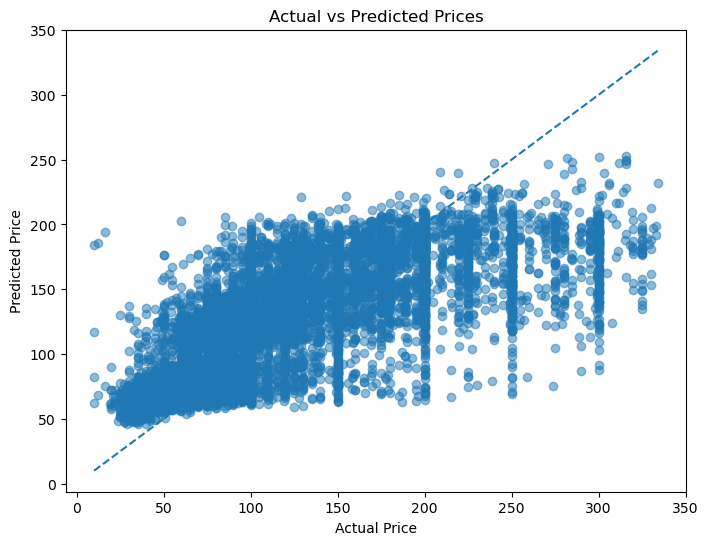

In [38]:
# Actual vs Predicted Price

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_final, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

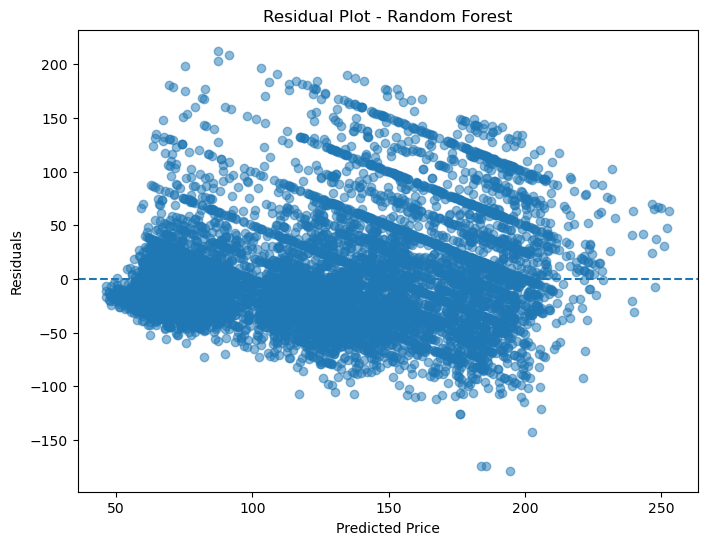

In [39]:
# Residual Analysis

residuals = y_test - y_pred_final

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_final, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.show()

In [41]:
# Feature Importance of Final Random Forest Model

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
229,cat__room_type_Entire home/apt,0.306292
230,cat__room_type_Private room,0.204427
1,num__longitude,0.117756
0,num__latitude,0.066876
9,cat__neighbourhood_group_Manhattan,0.049609
...,...,...
187,cat__neighbourhood_Silver Lake,0.000000
190,cat__neighbourhood_South Beach,0.000000
194,cat__neighbourhood_Spuyten Duyvil,0.000000
54,cat__neighbourhood_Co-op City,0.000000


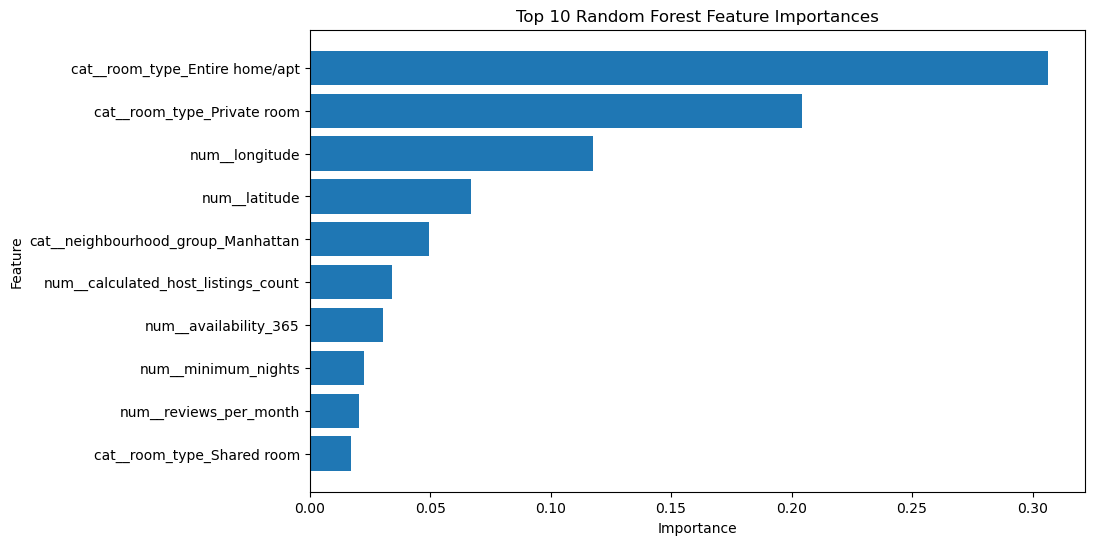

In [42]:
# Feature Importance Plot

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()

plt.show()

In [43]:
# --------------------------------------------------
# Save Final Model and Preprocessing Pipeline
# --------------------------------------------------

import joblib

# Save the final Random Forest model
joblib.dump(final_model, "airbnb_price_model.pkl")

# Save the preprocessing pipeline
joblib.dump(preprocessor, "airbnb_preprocessor.pkl")

print("Final model saved as: airbnb_price_model.pkl")
print("Preprocessing pipeline saved as: airbnb_preprocessor.pkl")

Final model saved as: airbnb_price_model.pkl
Preprocessing pipeline saved as: airbnb_preprocessor.pkl


In [44]:
import os

print("airbnb_price_model.pkl exists:",
      os.path.exists("airbnb_price_model.pkl"))

print("airbnb_preprocessor.pkl exists:",
      os.path.exists("airbnb_preprocessor.pkl"))

airbnb_price_model.pkl exists: True
airbnb_preprocessor.pkl exists: True


In [45]:
# --------------------------------------------------
# Test Final Model with a New Airbnb Listing
# --------------------------------------------------

# Load saved model and preprocessing pipeline
loaded_model = joblib.load("airbnb_price_model.pkl")
loaded_preprocessor = joblib.load("airbnb_preprocessor.pkl")

# Example new Airbnb listing
new_listing = pd.DataFrame({
    "neighbourhood_group": ["Manhattan"],
    "neighbourhood": ["Midtown"],
    "latitude": [40.7549],
    "longitude": [-73.9840],
    "room_type": ["Entire home/apt"],
    "minimum_nights": [2],
    "number_of_reviews": [50],
    "reviews_per_month": [2.5],
    "calculated_host_listings_count": [3],
    "availability_365": [200]
})

# Apply the saved preprocessing
new_listing_processed = loaded_preprocessor.transform(new_listing)

# Predict price
predicted_price = loaded_model.predict(new_listing_processed)[0]

print("Example Airbnb Listing")
print("----------------------")
display(new_listing)

print(f"\nEstimated Nightly Price: ${predicted_price:.2f}")

Example Airbnb Listing
----------------------


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Manhattan,Midtown,40.7549,-73.984,Entire home/apt,2,50,2.5,3,200



Estimated Nightly Price: $197.14


In [46]:
# --------------------------------------------------
# Model Comparison - RMSE
# --------------------------------------------------

comparison_df = results_df.copy()

# Add tuned Random Forest result
comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{
        "Model": "Tuned Random Forest",
        "MAE": mae_tuned,
        "RMSE": rmse_tuned,
        "R² Score": r2_tuned
    }])
], ignore_index=True)

print("Final Model Comparison:")
display(comparison_df)

Final Model Comparison:


,Model,MAE,RMSE,R² Score
0,Random Forest,31.539394,43.886839,0.574643
1,Ridge Regression,34.047380,46.398330,0.524567
2,Linear Regression,34.075562,46.426675,0.523986
3,Tuned Random Forest,32.719682,44.727040,0.558201


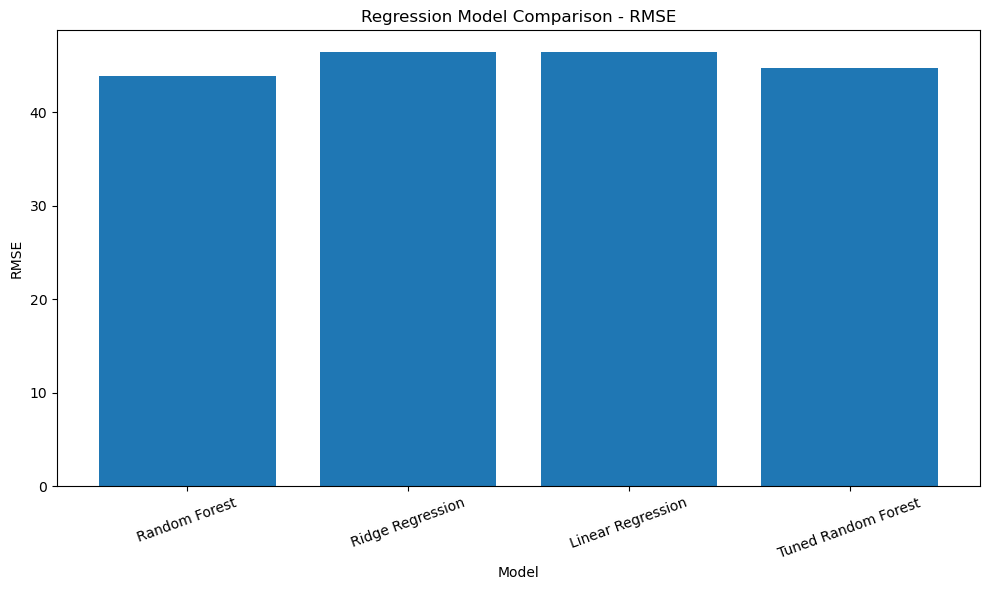

In [47]:
# --------------------------------------------------
# RMSE Comparison Chart
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Regression Model Comparison - RMSE")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

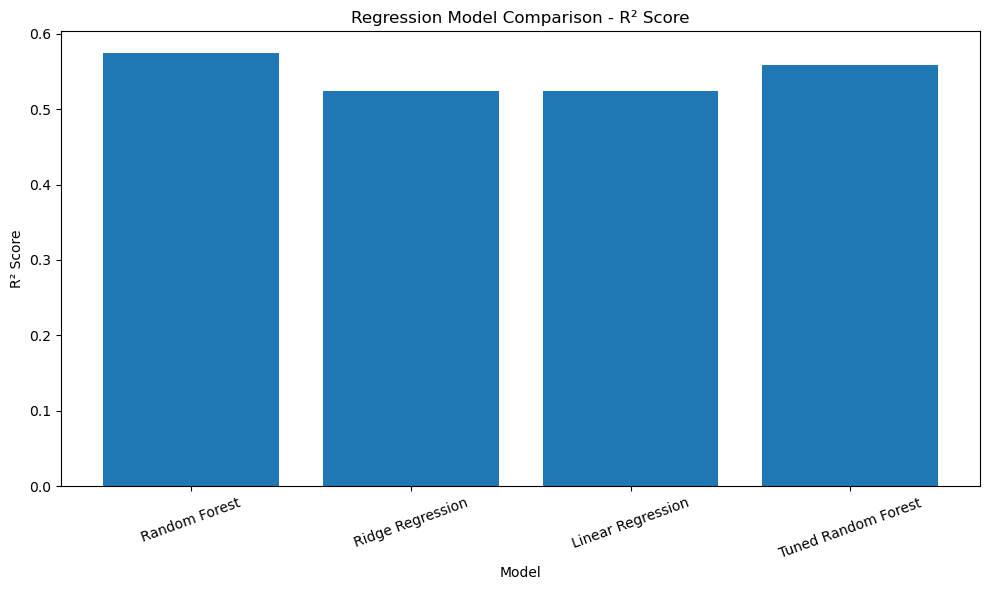

In [48]:
# --------------------------------------------------
# R² Score Comparison Chart
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["R² Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Regression Model Comparison - R² Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

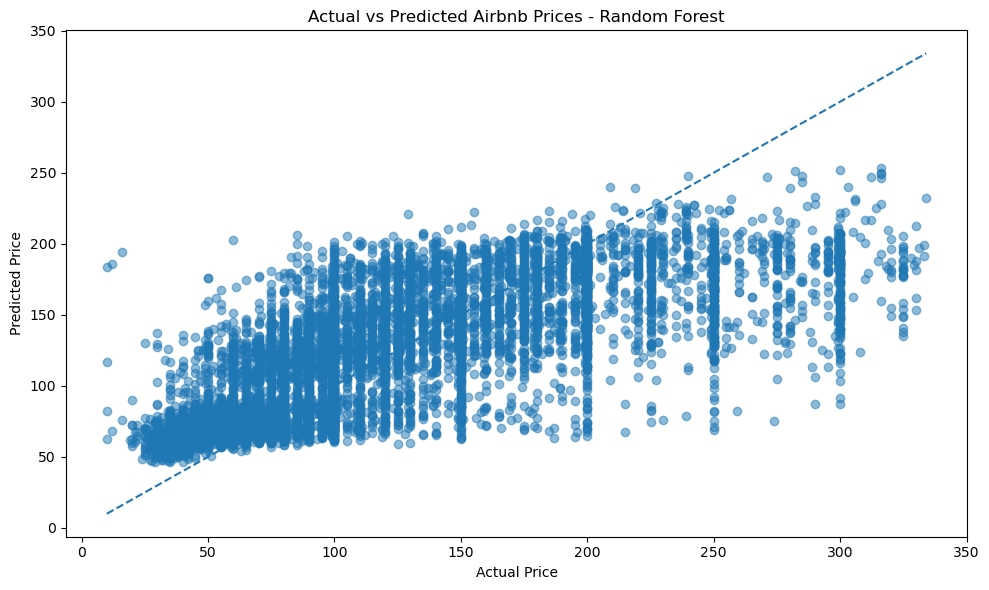

In [49]:
# --------------------------------------------------
# Actual vs Predicted Price - Final Model
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_final,
    alpha=0.5
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_final.min())
max_value = max(y_test.max(), y_pred_final.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices - Random Forest")

plt.tight_layout()
plt.show()

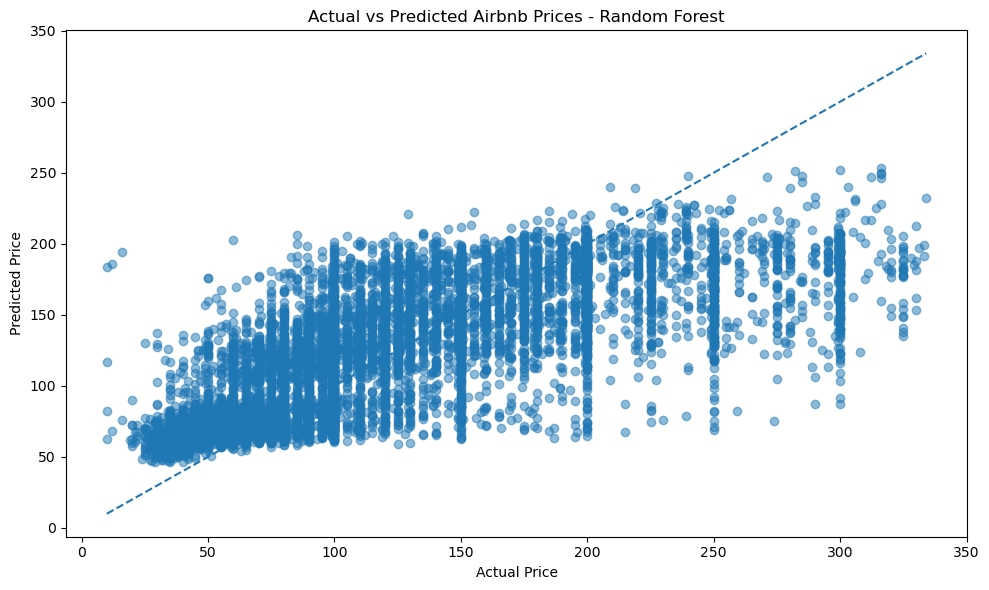

Plot saved as actual_vs_predicted.png


In [50]:
# --------------------------------------------------
# Save Final Model Evaluation Plot
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_final,
    alpha=0.5
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices - Random Forest")

plt.tight_layout()

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved as actual_vs_predicted.png")

In [51]:
# --------------------------------------------------
# Final Model Performance Summary
# --------------------------------------------------

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print("Final Model: Random Forest Regressor")
print(f"MAE       : {final_mae:.4f}")
print(f"RMSE      : {final_rmse:.4f}")
print(f"R² Score  : {final_r2:.4f}")

print("\nDataset Information")
print("-------------------")
print(f"Original rows       : {df.shape[0]}")
print(f"Rows after cleaning : {df_clean.shape[0]}")
print(f"Training rows       : {X_train.shape[0]}")
print(f"Testing rows        : {X_test.shape[0]}")

print("\nFinal model files")
print("-----------------")
print("airbnb_price_model.pkl")
print("airbnb_preprocessor.pkl")

FINAL MODEL PERFORMANCE
Final Model: Random Forest Regressor
MAE       : 32.7197
RMSE      : 44.7270
R² Score  : 0.5582

Dataset Information
-------------------
Original rows       : 48895
Rows after cleaning : 45912
Training rows       : 36729
Testing rows        : 9183

Final model files
-----------------
airbnb_price_model.pkl
airbnb_preprocessor.pkl


## Key Findings

1. The original Airbnb dataset contained 48,895 listings.

2. Listings with zero price were removed because they cannot represent a valid
   nightly Airbnb price.

3. Missing values were handled during data preprocessing. Missing
   `reviews_per_month` values were replaced with 0, while unnecessary
   `last_review` information was removed.

4. Extreme price outliers were identified using the IQR method and removed
   from the modeling dataset.

5. The final modeling dataset contained 45,912 listings.

6. Categorical variables such as neighbourhood group, neighbourhood, and room
   type were converted using OneHotEncoder.

7. Numerical variables were standardized using StandardScaler.

8. Three regression approaches were compared:
   Linear Regression, Ridge Regression, and Random Forest.

9. Random Forest achieved the best test-set performance among the evaluated
   models, with the lowest RMSE and highest R² score.

10. The Random Forest model was selected as the final prediction model.

## Limitations

- The model is trained using historical Airbnb listing data and may not
  represent current market prices.

- Price depends on many factors that may not be available in the dataset,
  such as seasonal demand, special events, amenities, property quality,
  and changes in the local market.

- Extreme prices were removed using the IQR method, so some genuine
  high-priced listings may have been excluded.

- The model provides an estimated nightly price and should not be considered
  a guaranteed market price.

- Model performance may decrease when predictions are made for listings
  whose characteristics differ substantially from the training data.

## Conclusion

This project developed an end-to-end machine learning workflow for predicting
Airbnb nightly prices using the New York City Airbnb Open Data dataset.

The workflow included data analysis, cleaning, missing-value handling,
outlier treatment, feature selection, preprocessing, regression model
comparison, hyperparameter tuning, model evaluation, and prediction testing.

Among the evaluated models, Random Forest provided the best test-set
performance and was selected as the final model. The trained model and
preprocessing pipeline were saved so that they can be reused for new Airbnb
listing inputs.

The next stage of the project is to integrate the saved model and
preprocessing pipeline into a Streamlit web application for interactive
Airbnb price prediction.